### General Results of the optimisation

In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

# Get latest run
RESULTS_ROOT = Path("02-MODEL-RESULTS")
latest_run = sorted([d for d in RESULTS_ROOT.iterdir() if d.is_dir()])[-1]

# Load summary and settings
with open(latest_run / "results_summary.json", "r") as f:
    summary = json.load(f)
with open(latest_run / "settings_snapshot.json", "r") as f:
    settings = json.load(f)
active_parameters = settings.get("parameters", {})

# Load time series
df = pd.read_csv(latest_run / "timeseries_results.csv", parse_dates=['timestamp'])
df_soc = df.copy()
df_compare = pd.read_csv(latest_run / "baseline_vs_optimized.csv")
df_peak_metrics = pd.read_csv(latest_run / "peak_metrics.csv")
df_top_peaks = pd.read_csv(latest_run / "top_peak_intervals.csv", parse_dates=['timestamp'])
timestep_hours = pd.Series(pd.to_datetime(df["timestamp"])).diff().dropna().dt.total_seconds().median() / 3600 if "timestamp" in df.columns and len(df) > 1 else 0.25
monthly_summary_path = latest_run / "monthly_summary.csv"
if monthly_summary_path.exists():
    df_monthly = pd.read_csv(monthly_summary_path)
else:
    df_monthly = df.copy()
    df_monthly["month"] = df_monthly["timestamp"].dt.to_period("M").astype(str)
    price_per_kwh = 0.0
    if len(df_monthly) > 0 and df_monthly["grid_flow"].sum() > 0:
        price_per_kwh = summary.get("import_cost", 0.0) / (df_monthly["grid_flow"].sum() * 0.25)
    df_monthly["baseline_import_cost"] = df_monthly["baseline_grid_import"] * price_per_kwh * 0.25
    df_monthly["optimized_import_cost"] = df_monthly["grid_flow"] * price_per_kwh * 0.25
    df_monthly = df_monthly.groupby("month", as_index=False).agg(
        monthly_import_cost_before=("baseline_import_cost", "sum"),
        monthly_import_cost_after=("optimized_import_cost", "sum"),
        monthly_peak_before=("baseline_grid_import", "max"),
        monthly_peak_after=("grid_flow", "max"),
    )
    df_monthly["monthly_savings"] = df_monthly["monthly_import_cost_before"] - df_monthly["monthly_import_cost_after"]
    df_monthly["monthly_peak_reduction"] = df_monthly["monthly_peak_before"] - df_monthly["monthly_peak_after"]
battery_utilization_path = latest_run / "battery_utilization_summary.csv"
if battery_utilization_path.exists():
    df_battery_util = pd.read_csv(battery_utilization_path)
elif {"battery_soc", "battery_charge_power", "battery_discharge_power"}.issubset(df.columns):
    installed_capacity = summary.get("battery_capacity_kwh", 0.0)
    avg_soc = df["battery_soc"].mean()
    min_soc = df["battery_soc"].min()
    max_soc = df["battery_soc"].max()
    discharged_energy = df["battery_discharge_power"].sum() * timestep_hours
    charged_energy = df["battery_charge_power"].sum() * timestep_hours
    equivalent_cycles = discharged_energy / installed_capacity if installed_capacity else float("nan")
    df_battery_util = pd.DataFrame([
        {"Metric": "Charged energy", "Value": charged_energy, "Unit": "kWh/year"},
        {"Metric": "Discharged energy", "Value": discharged_energy, "Unit": "kWh/year"},
        {"Metric": "Equivalent full cycles", "Value": equivalent_cycles, "Unit": "cycles/year"},
        {"Metric": "Average state of charge", "Value": avg_soc, "Unit": "kWh"},
        {"Metric": "Minimum state of charge", "Value": min_soc, "Unit": "kWh"},
        {"Metric": "Maximum state of charge", "Value": max_soc, "Unit": "kWh"},
        {"Metric": "Hours near empty (<=10%)", "Value": (df["battery_soc"] <= 0.10 * installed_capacity).sum() * timestep_hours, "Unit": "hours"},
        {"Metric": "Hours near full (>=90%)", "Value": (df["battery_soc"] >= 0.90 * installed_capacity).sum() * timestep_hours, "Unit": "hours"},
        {"Metric": "Maximum charge power used", "Value": df["battery_charge_power"].max(), "Unit": "kW"},
        {"Metric": "Maximum discharge power used", "Value": df["battery_discharge_power"].max(), "Unit": "kW"},
    ])
else:
    df_battery_util = pd.DataFrame(columns=["Metric", "Value", "Unit"])
battery_sensitivity_path = latest_run / "battery_size_sensitivity.csv"
if battery_sensitivity_path.exists():
    df_battery_sensitivity = pd.read_csv(battery_sensitivity_path)
else:
    df_battery_sensitivity = pd.DataFrame(columns=["battery_size_kwh", "objective_total_cost", "import_cost", "peak_demand_cost", "annualized_battery_cost", "annual_savings", "npv", "irr", "payback_years", "discounted_payback_years", "status"])
df_fin = pd.read_csv(latest_run / "financial_cashflows.csv")

def infer_timestep_hours(timestamp_series, default_hours=0.25):
    if timestamp_series is None or len(timestamp_series) < 2:
        return default_hours
    deltas = pd.Series(pd.to_datetime(timestamp_series)).diff().dropna()
    if deltas.empty:
        return default_hours
    step_hours = deltas.dt.total_seconds().median() / 3600
    return float(step_hours) if step_hours > 0 else default_hours

def format_duration(hours_value):
    if pd.isna(hours_value):
        return "-"
    hours_value = float(hours_value)
    abs_value = abs(hours_value)
    if abs_value < 1:
        return f"{hours_value * 60:,.0f} min"
    if abs_value < 48:
        return f"{hours_value:,.0f} h"
    if abs_value < 24 * 21:
        return f"{hours_value / 24:,.1f} d"
    return f"{hours_value / (24 * 7):,.1f} w"

def duration_tick_formatter(value, _):
    return format_duration(value)

timestep_hours = infer_timestep_hours(df["timestamp"]) if "timestamp" in df.columns else timestep_hours

for required_col in ["pv_flow", "grid_flow", "battery_charge_power", "battery_discharge_power", "total_load"]:
    if required_col not in df.columns:
        df[required_col] = 0.0
if "spill_flow" not in df.columns:
    df["spill_flow"] = 0.0
if "electricity_price" not in df.columns:
    df["electricity_price"] = 0.0

run_metadata = {
    "timestamp": settings.get("timestamp"),
    "timesteps_used": settings.get("timesteps_used"),
    "load_existing_input_dict": settings.get("load_existing_input_dict"),
    "max_timesteps": settings.get("max_timesteps"),
    "debug_infeasibility": settings.get("debug_infeasibility"),
}
settings_table_df = pd.DataFrame(
    [{"Section": "Run Metadata", "Name": key, "Value": value} for key, value in run_metadata.items()]
    + [{"Section": "Model Parameter", "Name": key, "Value": value} for key, value in active_parameters.items()]
)
detailed_summary_df = pd.DataFrame([
    {
        "Metric": key,
        "Value": json.dumps(value) if isinstance(value, (dict, list)) else value,
    }
    for key, value in summary.items()
])

dispatch_df = df.copy()
dispatch_df["week_start"] = dispatch_df["timestamp"].dt.to_period("W").apply(lambda p: p.start_time)
weekly_summary = dispatch_df.groupby("week_start", as_index=False).agg(
    total_load=("total_load", "sum"),
    total_pv=("pv_flow", "sum"),
    total_grid_import=("grid_flow", "sum"),
    total_battery_charge=("battery_charge_power", "sum"),
    total_battery_discharge=("battery_discharge_power", "sum"),
    total_curtailment=("spill_flow", "sum"),
    avg_price=("electricity_price", "mean"),
    peak_load=("total_load", "max"),
)
weekly_summary["month"] = weekly_summary["week_start"].dt.month

def _pick_week(label, candidate_df, sort_columns):
    if candidate_df.empty:
        return None
    ordered = candidate_df.sort_values(sort_columns, ascending=[False] * len(sort_columns)).iloc[0]
    return {"label": label, "week_start": ordered["week_start"]}

week_candidates = [
    _pick_week("Winter Week", weekly_summary[weekly_summary["month"].isin([12, 1, 2])], ["total_load", "peak_load"]),
    _pick_week("Summer Week", weekly_summary[weekly_summary["month"].isin([6, 7, 8])], ["total_pv", "total_load"]),
    _pick_week("Highest-Load Week", weekly_summary, ["total_load", "peak_load"]),
    _pick_week("Highest-Price Week", weekly_summary, ["avg_price", "total_grid_import"]),
    _pick_week("Highest-Curtailment Week", weekly_summary, ["total_curtailment", "total_pv"]),
]
selected_dispatch_weeks = []
seen_week_starts = set()
for candidate in week_candidates:
    if candidate is None:
        continue
    week_start = candidate["week_start"]
    if week_start in seen_week_starts:
        continue
    seen_week_starts.add(week_start)
    selected_dispatch_weeks.append(candidate)
dispatch_week_table = pd.DataFrame(selected_dispatch_weeks)

print(f"Loaded results from: {latest_run.name}")

Loaded results from: 20260415_144431_lp_35137steps


In [2]:
from IPython.display import display, Markdown

def format_value(v):
    if isinstance(v, bool):
        return "Yes" if v else "No"
    if pd.isna(v):
        return "-"
    if isinstance(v, (int, float)):
        return f"{v:,.2f}"
    return v

display(Markdown("## Baseline vs Optimized Comparison"))
display(df_compare.style.format({
    "Baseline": format_value,
    "Optimized": format_value,
    "Optimized - Baseline": format_value,
}))


supplementary_kpis = [
    ("Battery energy size [kWh]", "battery_capacity_kwh"),
    ("Battery power rating [kW]", "battery_power_capacity_kw"),
    ("Annual Savings", "annual_savings"),
    ("Equivalent Full Cycles", "equivalent_full_cycles"),
    ("Replacement Basis", "replacement_basis"),
    ("Energy CAPEX [CHF]", "energy_investment_cost"),
    ("Power CAPEX [CHF]", "power_investment_cost"),
    ("Curtailed Energy (kWh)", "curtailed_energy_kwh"),
    ("Annual Peak", "yearly_peak"),
    ("Replacement Cost", "replacement_cost"),
    ("Replacement Year", "replacement_year"),
    ("IRR", "irr"),
]
kpi_df = pd.DataFrame([
    {"Metric": label, "Value": summary.get(key)}
    for label, key in supplementary_kpis
])

display(Markdown("## Supplementary KPIs"))
display(kpi_df.style.format({"Value": format_value}))

display(Markdown("## Run and Model Settings"))
display(settings_table_df.style.format({"Value": format_value}))

## Baseline vs Optimized Comparison

,Metric,Baseline,Optimized,Optimized - Baseline,Unit
0,Battery size,0.00,"2,328.00","2,328.00",kWh
1,Battery power rating,0.00,397.32,397.32,kW
2,Annual import cost,"678,200.83","582,497.79","-95,703.04",CHF/year
3,Total annual cost,"695,643.83","660,865.93","-34,777.91",CHF/year
4,Annual peak-demand cost,"17,443.00","13,469.82","-3,973.19",CHF/year
5,Annual import cost savings,0.00,"95,703.04","95,703.04",CHF/year
6,Annual total cost reduction,0.00,"34,777.91","34,777.91",CHF/year
7,CAPEX,0.00,"629,679.43","629,679.43",CHF
8,CAPEX energy component,0.00,"582,001.17","582,001.17",CHF
9,CAPEX power component,0.00,"47,678.27","47,678.27",CHF


## Supplementary KPIs

,Metric,Value
0,Battery energy size [kWh],"2,328.00"
1,Battery power rating [kW],397.32
2,Annual Savings,"89,676.23"
3,Equivalent Full Cycles,170.61
4,Replacement Basis,calendar_life
5,Energy CAPEX [CHF],"582,001.17"
6,Power CAPEX [CHF],"47,678.27"
7,Curtailed Energy (kWh),"83,821.20"
8,Annual Peak,"1,346.98"
9,Replacement Cost,"440,775.60"


## Run and Model Settings

,Section,Name,Value
0,Run Metadata,timestamp,2026-04-15T14:45:31
1,Run Metadata,timesteps_used,"35,137.00"
2,Run Metadata,load_existing_input_dict,Yes
3,Run Metadata,max_timesteps,-
4,Run Metadata,debug_infeasibility,No
5,Model Parameter,PV_max_capacity,"10,000.00"
6,Model Parameter,Battery_max_inflow,"1,000.00"
7,Model Parameter,Battery_max_outflow,"1,000.00"
8,Model Parameter,Battery_max_capacity,"100,000.00"
9,Model Parameter,battery_max_c_rate,0.50


In [3]:
display(Markdown("## Peak Import Before vs After Battery"))
display(df_peak_metrics.style.format({
    "Before battery": format_value,
    "After battery": format_value,
    "Reduction": format_value,
    "Reduction %": format_value,
}))

display(Markdown("### Top 10 Peak Intervals Reduced"))
display(df_top_peaks.head(10).style.format({
    "baseline_grid_import": format_value,
    "optimized_grid_import": format_value,
    "peak_reduction": format_value,
}))

## Peak Import Before vs After Battery

,Metric,Before battery,After battery,Reduction,Reduction %,Unit
0,Maximum grid import,"1,744.30","1,346.98",397.32,22.78,kW
1,95th percentile grid import,999.85,994.02,5.83,0.58,kW


### Top 10 Peak Intervals Reduced

,timestamp,baseline_grid_import,optimized_grid_import,peak_reduction
0,2024-07-09 23:30:00,558.48,161.16,397.32
1,2024-07-05 23:30:00,545.28,147.96,397.32
2,2024-08-02 22:00:00,929.31,531.99,397.32
3,2024-08-29 20:45:00,867.55,470.23,397.32
4,2024-08-02 22:30:00,936.46,539.14,397.32
5,2024-08-02 23:30:00,567.81,170.49,397.32
6,2024-03-13 19:30:00,884.30,486.98,397.32
7,2024-08-06 22:30:00,911.69,514.37,397.32
8,2024-08-06 22:15:00,918.03,520.71,397.32
9,2024-08-20 23:30:00,556.76,159.44,397.32


## Grid Import Duration Curve

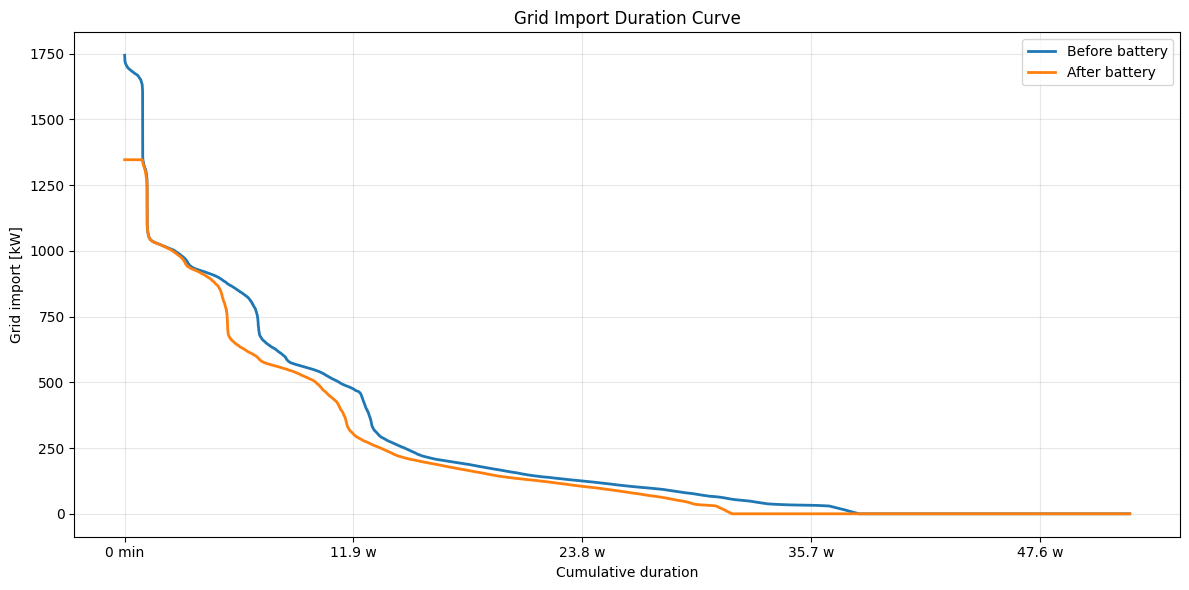

In [4]:
display(Markdown("## Grid Import Duration Curve"))

baseline_duration = df["baseline_grid_import"].sort_values(ascending=False).reset_index(drop=True)
optimized_duration = df["grid_flow"].sort_values(ascending=False).reset_index(drop=True)
duration_axis_hours = pd.Series(np.arange(1, len(baseline_duration) + 1) * timestep_hours)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(duration_axis_hours, baseline_duration, label="Before battery", linewidth=2)
ax.plot(duration_axis_hours, optimized_duration, label="After battery", linewidth=2)
ax.set_xlabel("Cumulative duration")
ax.set_ylabel("Grid import [kW]")
ax.set_title("Grid Import Duration Curve")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(duration_tick_formatter))
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
display(Markdown("## Monthly Savings and Peak Reduction"))
display(df_monthly.style.format({
    "monthly_import_cost_before": format_value,
    "monthly_import_cost_after": format_value,
    "monthly_savings": format_value,
    "monthly_peak_before": format_value,
    "monthly_peak_after": format_value,
    "monthly_peak_reduction": format_value,
}))

## Monthly Savings and Peak Reduction

,month,monthly_import_cost_before,monthly_import_cost_after,monthly_savings,monthly_peak_before,monthly_peak_after,monthly_peak_reduction
0,2024-01,"70,589.25","69,262.99","1,326.26","1,704.81","1,346.98",357.83
1,2024-02,"60,567.41","54,357.48","6,209.93","1,710.51","1,346.98",363.53
2,2024-03,"58,841.98","49,376.32","9,465.66","1,699.59","1,346.98",352.61
3,2024-04,"47,959.72","35,664.06","12,295.66","1,105.51","1,105.51",0.00
4,2024-05,"47,867.65","35,564.29","12,303.37","1,081.39","1,081.39",-0.00
5,2024-06,"42,686.35","30,465.45","12,220.90","1,033.82","1,033.82",0.00
6,2024-07,"47,271.79","32,625.99","14,645.80","1,048.24","1,048.24",-0.00
7,2024-08,"46,918.89","32,898.94","14,019.95","1,042.85","1,042.85",0.00
8,2024-09,"46,896.26","37,712.95","9,183.31","1,062.53","1,062.53",0.00
9,2024-10,"64,052.08","59,041.27","5,010.81","1,719.56","1,346.98",372.58


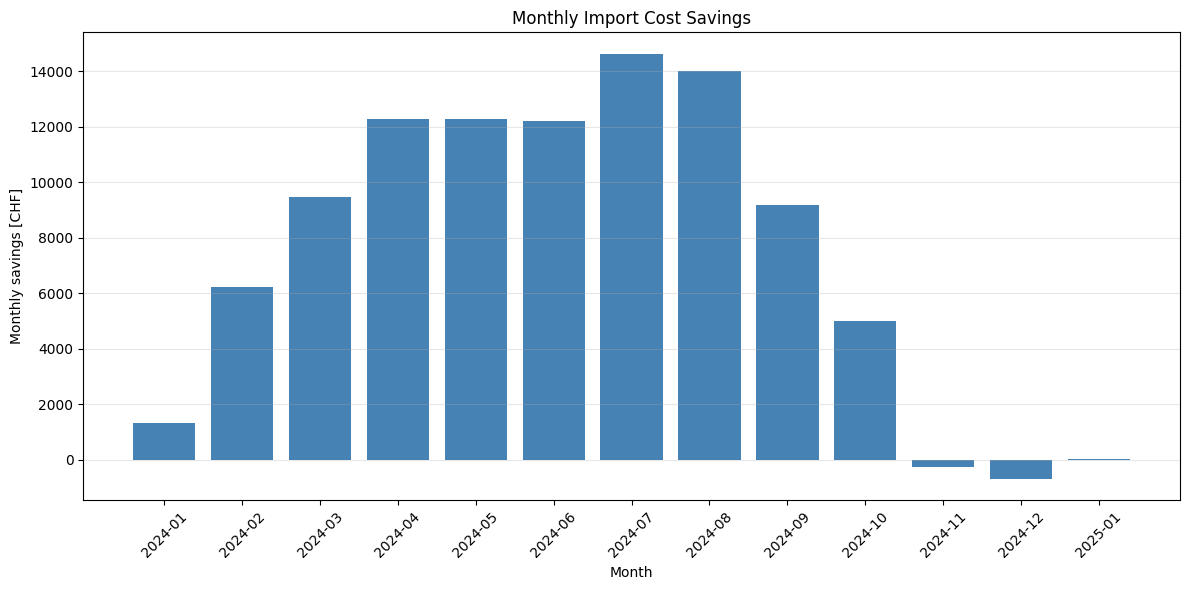

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(df_monthly["month"], df_monthly["monthly_savings"], color="steelblue")
ax.set_xlabel("Month")
ax.set_ylabel("Monthly savings [CHF]")
ax.set_title("Monthly Import Cost Savings")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
display(Markdown("## Battery Utilization Metrics"))
display(df_battery_util.style.format({"Value": format_value}))

## Battery Utilization Metrics

,Metric,Value,Unit
0,Charged energy,"464,515.17",kWh/year
1,Discharged energy,"397,169.71",kWh/year
2,Equivalent full cycles,170.61,cycles/year
3,Average state of charge,881.75,kWh
4,Minimum state of charge,465.60,kWh
5,Maximum state of charge,"2,328.00",kWh
6,Hours near empty (<=10%),0.00,hours
7,Hours near full (>=90%),451.25,hours
8,Maximum charge power used,397.32,kW
9,Maximum discharge power used,397.32,kW


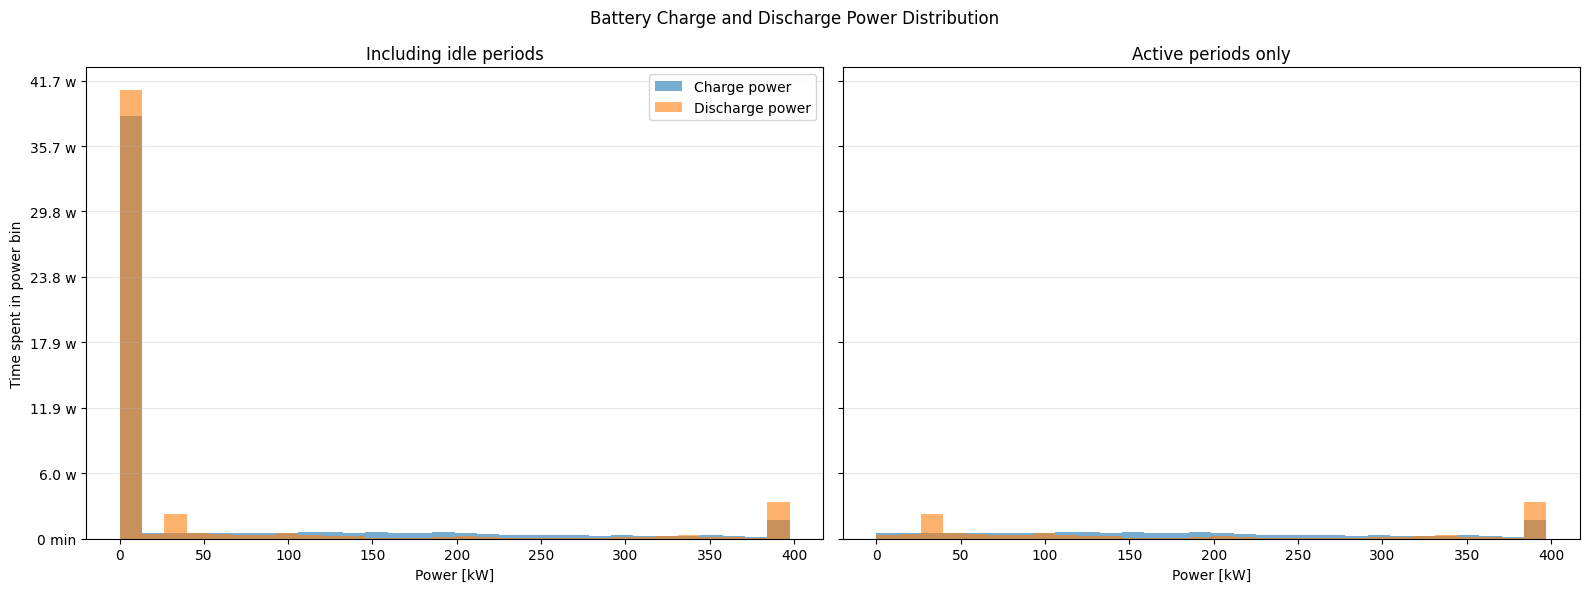

In [8]:
if {"battery_charge_power", "battery_discharge_power"}.issubset(df.columns):
    charge_power_all = df["battery_charge_power"]
    discharge_power_all = df["battery_discharge_power"]
    charge_power_active = df.loc[df["battery_charge_power"] > 1e-9, "battery_charge_power"]
    discharge_power_active = df.loc[df["battery_discharge_power"] > 1e-9, "battery_discharge_power"]

    combined_power = pd.concat([charge_power_all, discharge_power_all], ignore_index=True)
    if combined_power.empty:
        common_bins = 30
    else:
        power_min = float(combined_power.min())
        power_max = float(combined_power.max())
        if np.isclose(power_min, power_max):
            power_max = power_min + 1.0
        common_bins = np.linspace(power_min, power_max, 31)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)
    plot_configs = [
        (axes[0], charge_power_all, discharge_power_all, "Including idle periods"),
        (axes[1], charge_power_active, discharge_power_active, "Active periods only"),
    ]

    for ax, charge_series, discharge_series, subtitle in plot_configs:
        if not charge_series.empty:
            ax.hist(
                charge_series,
                bins=common_bins,
                weights=np.full(len(charge_series), timestep_hours),
                alpha=0.6,
                label="Charge power",
                color="tab:blue",
            )
        if not discharge_series.empty:
            ax.hist(
                discharge_series,
                bins=common_bins,
                weights=np.full(len(discharge_series), timestep_hours),
                alpha=0.6,
                label="Discharge power",
                color="tab:orange",
            )
        ax.set_xlabel("Power [kW]")
        ax.set_title(subtitle)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(duration_tick_formatter))
        ax.grid(axis="y", alpha=0.3)

    axes[0].set_ylabel("Time spent in power bin")
    axes[0].legend()
    fig.suptitle("Battery Charge and Discharge Power Distribution")
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("_Run the model again to generate charge/discharge power distributions for this section._"))

In [9]:
display(Markdown("## Battery Size Sensitivity"))
if df_battery_sensitivity.empty:
    display(Markdown("_Run the model again to generate the battery size sensitivity analysis._"))
else:
    sensitivity_formatters = {
        "battery_size_kwh": format_value,
        "optimized_battery_capacity_kwh": format_value,
        "optimized_battery_power_capacity_kw": format_value,
        "objective_total_cost": format_value,
        "import_cost": format_value,
        "peak_demand_cost": format_value,
        "annualized_battery_cost": format_value,
        "annual_savings": format_value,
        "npv": format_value,
        "irr": format_value,
        "payback_years": format_value,
        "discounted_payback_years": format_value,
    }
    sensitivity_formatters = {key: value for key, value in sensitivity_formatters.items() if key in df_battery_sensitivity.columns}
    display(df_battery_sensitivity.style.format(sensitivity_formatters))

## Battery Size Sensitivity

_Run the model again to generate the battery size sensitivity analysis._

In [10]:
plot_df = df_battery_sensitivity[df_battery_sensitivity["status"].isin(["baseline", "optimal"])].copy() if not df_battery_sensitivity.empty else df_battery_sensitivity
if not plot_df.empty:
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.plot(plot_df["battery_size_kwh"], plot_df["annual_savings"], marker="o", color="tab:blue")
    ax1.set_xlabel("Battery size [kWh]")
    ax1.set_ylabel("Annual savings [CHF/year]", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(plot_df["battery_size_kwh"], plot_df["npv"], marker="s", color="tab:red")
    ax2.set_ylabel("NPV [CHF]", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    plt.title("Sensitivity Plot of Battery Size vs NPV / Annual Savings")
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("_No sensitivity results available yet for this run._"))

_No sensitivity results available yet for this run._

## Representative Dispatch Weeks

,label,week_start
0,Winter Week,2024-12-09
1,Summer Week,2024-08-12
2,Highest-Curtailment Week,2024-05-06


Each representative week is split into three panels: (1) site demand and supply sources, (2) battery charging and discharging around a zero line, and (3) battery state of charge with the electricity price as dashed reference.

### Winter Week | Week of 2024-12-09  Peak load: **1,732 kW**, total load: **58,267 kWh**, PV used: **324 kWh**, grid import: **58,307 kWh**, battery charge/discharge: **2,499 / 2,135 kWh**, average price: **0.300 CHF/kWh**

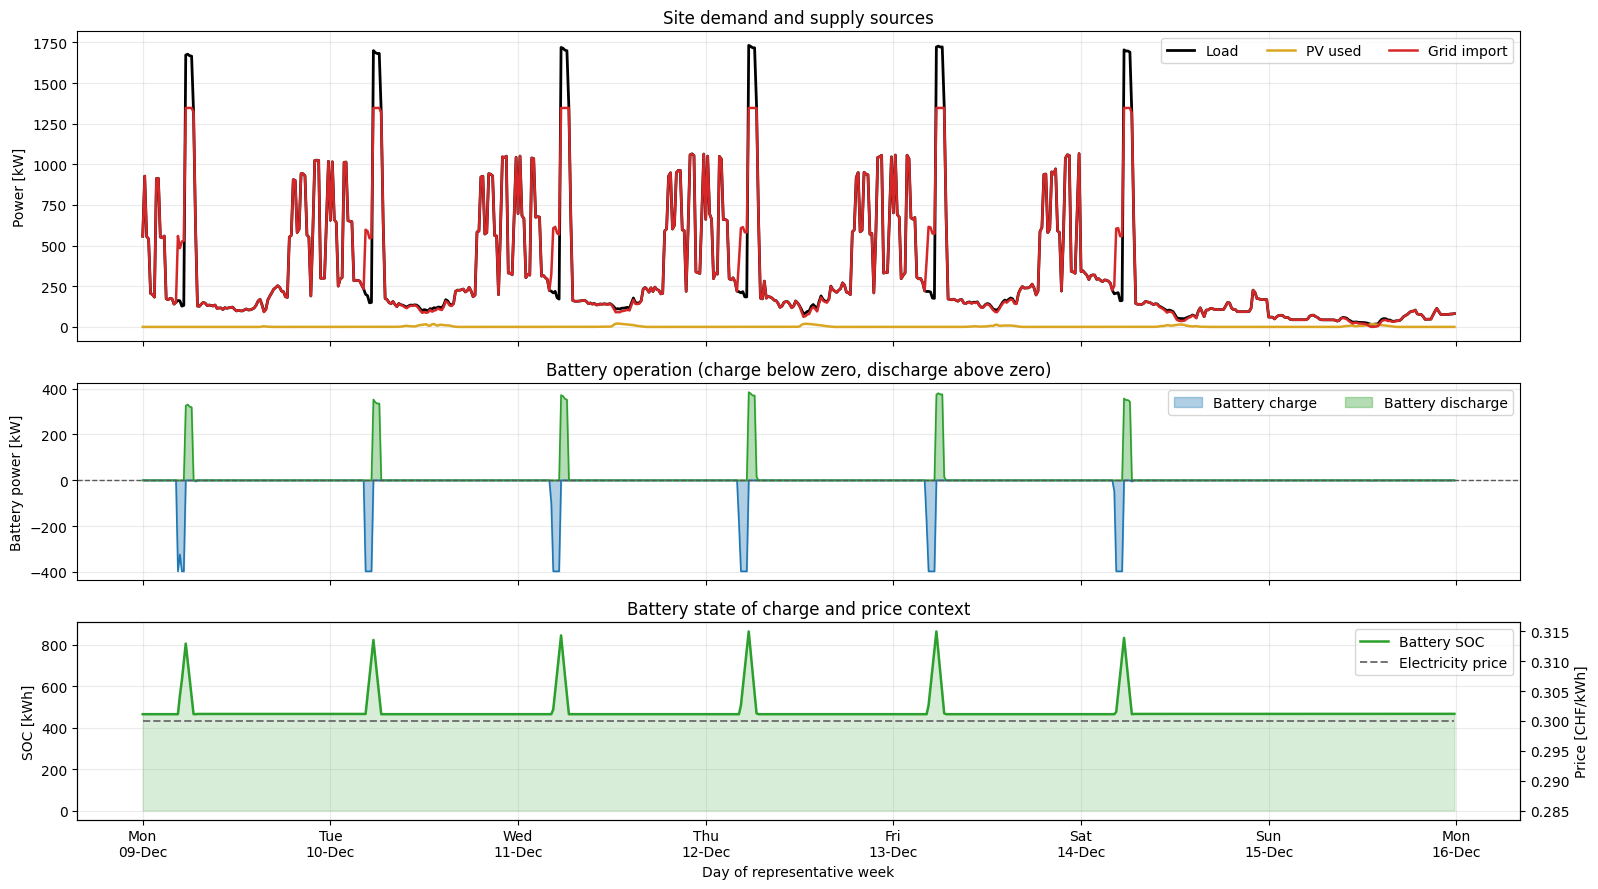

### Summer Week | Week of 2024-08-12  Peak load: **1,038 kW**, total load: **32,955 kWh**, PV used: **8,683 kWh**, grid import: **25,725 kWh**, battery charge/discharge: **11,740 / 10,287 kWh**, average price: **0.300 CHF/kWh**

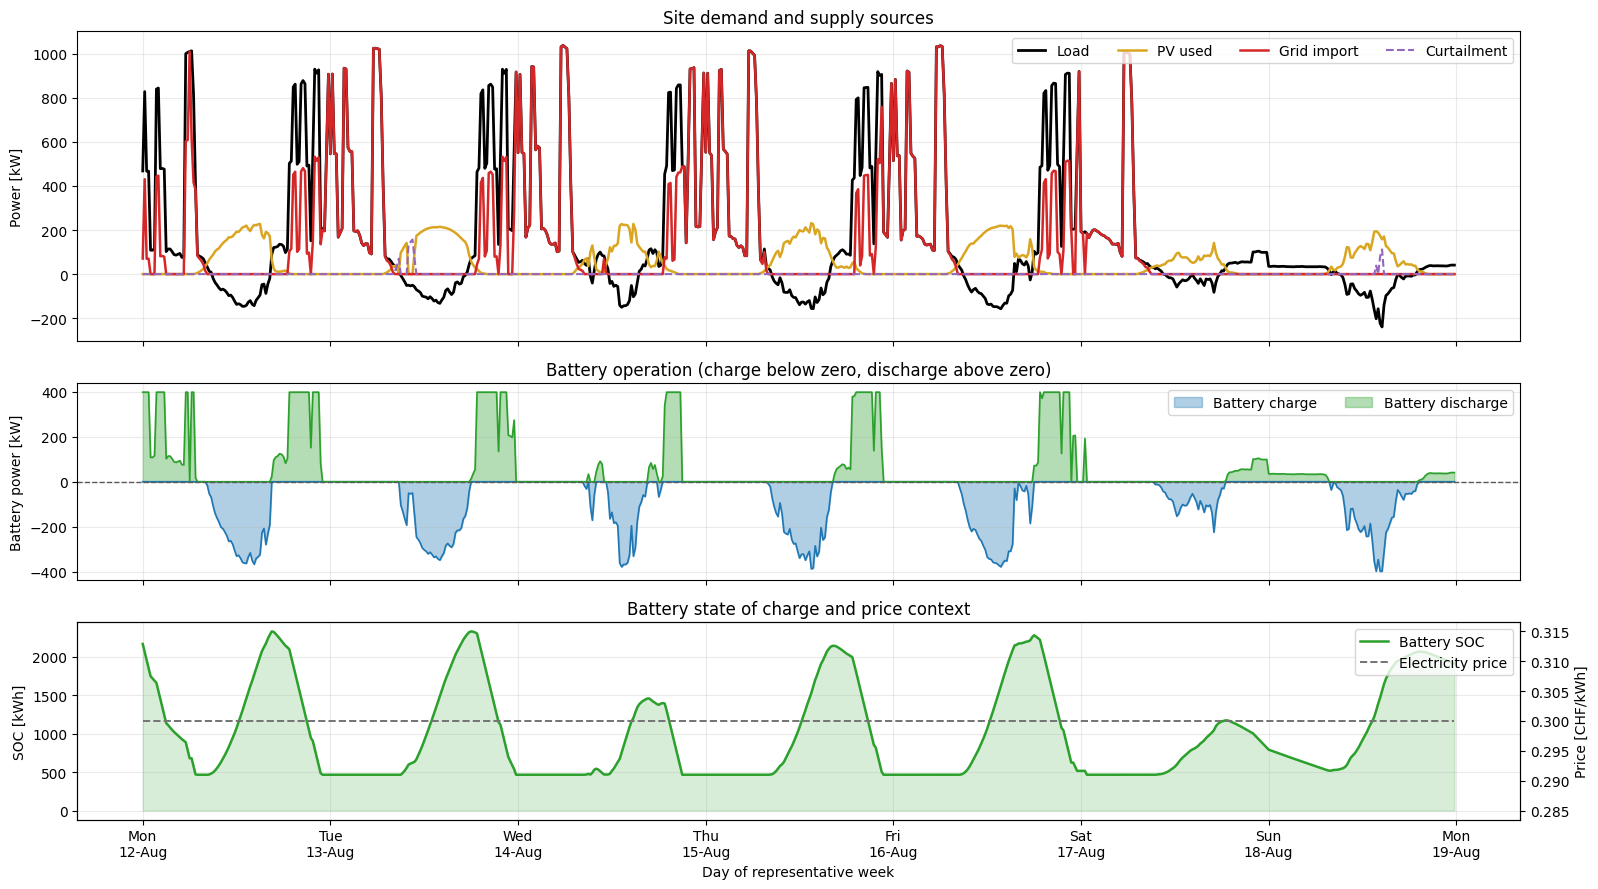

### Highest-Curtailment Week | Week of 2024-05-06  Peak load: **1,082 kW**, total load: **28,585 kWh**, PV used: **4,581 kWh**, grid import: **26,466 kWh**, battery charge/discharge: **17,048 / 14,585 kWh**, average price: **0.300 CHF/kWh**

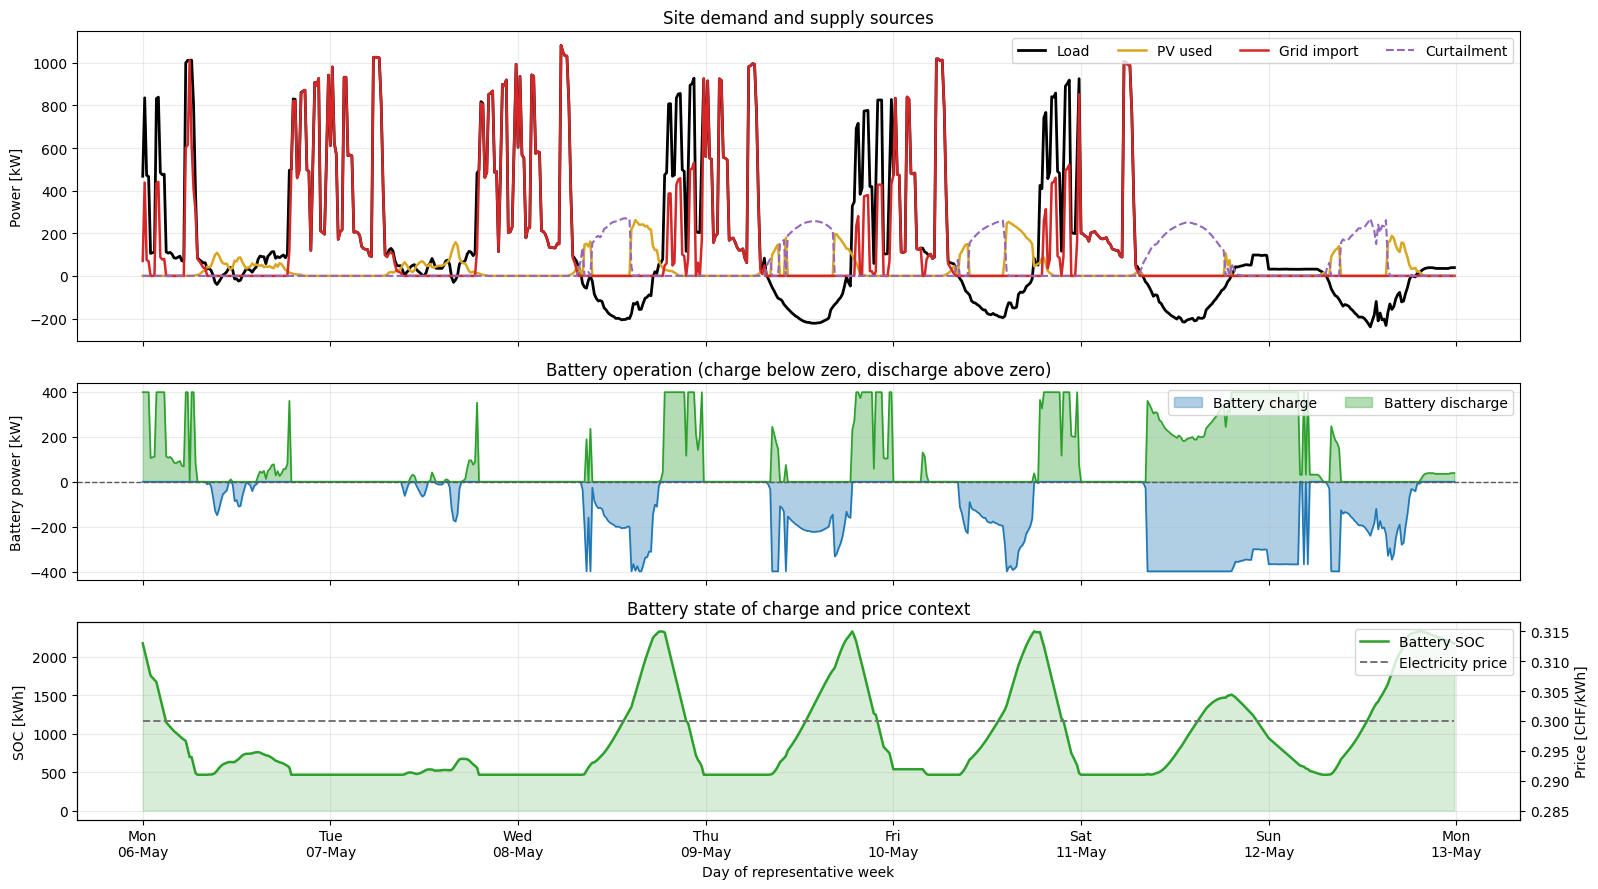

In [11]:
display(Markdown("## Representative Dispatch Weeks"))
if dispatch_week_table.empty:
    display(Markdown("_No representative dispatch weeks could be identified for this run._"))
else:
    display(dispatch_week_table.style.format({"week_start": lambda v: pd.to_datetime(v).strftime('%Y-%m-%d')}))
    display(Markdown(
        "Each representative week is split into three panels: "
        "(1) site demand and supply sources, "
        "(2) battery charging and discharging around a zero line, and "
        "(3) battery state of charge with the electricity price as dashed reference."
    ))

    for week_info in selected_dispatch_weeks:
        start = pd.to_datetime(week_info["week_start"])
        end = start + pd.Timedelta(days=7)
        week_df = dispatch_df[(dispatch_df["timestamp"] >= start) & (dispatch_df["timestamp"] < end)].copy()

        if week_df.empty:
            display(Markdown(f"### {week_info['label']}"))
            display(Markdown("_No data available for this representative week._"))
            continue

        total_load = week_df["total_load"].sum() * timestep_hours
        avg_price = week_df["electricity_price"].mean()
        peak_load = week_df["total_load"].max()
        total_grid_import = week_df["grid_flow"].sum() * timestep_hours
        total_pv_used = week_df["pv_flow"].sum() * timestep_hours
        total_charge = week_df["battery_charge_power"].sum() * timestep_hours
        total_discharge = week_df["battery_discharge_power"].sum() * timestep_hours

        display(Markdown(
            f"### {week_info['label']} | Week of {start.strftime('%Y-%m-%d')}  "
            f"Peak load: **{peak_load:,.0f} kW**, total load: **{total_load:,.0f} kWh**, "
            f"PV used: **{total_pv_used:,.0f} kWh**, grid import: **{total_grid_import:,.0f} kWh**, "
            f"battery charge/discharge: **{total_charge:,.0f} / {total_discharge:,.0f} kWh**, "
            f"average price: **{avg_price:,.3f} CHF/kWh**"
        ))

        fig, axes = plt.subplots(
            3,
            1,
            figsize=(16, 9),
            sharex=True,
            gridspec_kw={"height_ratios": [2.2, 1.4, 1.4]},
        )
        ax_supply, ax_battery, ax_soc = axes

        ax_supply.plot(week_df["timestamp"], week_df["total_load"], label="Load", color="black", linewidth=2.0)
        ax_supply.plot(week_df["timestamp"], week_df["pv_flow"], label="PV used", color="goldenrod", linewidth=1.8)
        ax_supply.plot(week_df["timestamp"], week_df["grid_flow"], label="Grid import", color="tab:red", linewidth=1.8)
        if (week_df["spill_flow"] > 1e-9).any():
            ax_supply.plot(
                week_df["timestamp"],
                week_df["spill_flow"],
                label="Curtailment",
                color="tab:purple",
                linewidth=1.5,
                linestyle="--",
            )
        ax_supply.set_ylabel("Power [kW]")
        ax_supply.set_title("Site demand and supply sources")
        ax_supply.grid(True, alpha=0.25)
        ax_supply.legend(loc="upper right", ncol=4)

        charge_series = -week_df["battery_charge_power"].to_numpy(dtype=float)
        discharge_series = week_df["battery_discharge_power"].to_numpy(dtype=float)
        ax_battery.fill_between(week_df["timestamp"], 0, charge_series, color="tab:blue", alpha=0.35, label="Battery charge")
        ax_battery.fill_between(week_df["timestamp"], 0, discharge_series, color="tab:green", alpha=0.35, label="Battery discharge")
        ax_battery.plot(week_df["timestamp"], charge_series, color="tab:blue", linewidth=1.2)
        ax_battery.plot(week_df["timestamp"], discharge_series, color="tab:green", linewidth=1.2)
        ax_battery.axhline(0, color="0.35", linewidth=1.0, linestyle="--")
        ax_battery.set_ylabel("Battery power [kW]")
        ax_battery.set_title("Battery operation (charge below zero, discharge above zero)")
        ax_battery.grid(True, alpha=0.25)
        ax_battery.legend(loc="upper right", ncol=2)

        ax_soc.plot(week_df["timestamp"], week_df["battery_soc"], color="#2ca02c", lw=1.8, label="Battery SOC")
        ax_soc.fill_between(week_df["timestamp"], week_df["battery_soc"], alpha=0.18, color="#2ca02c")
        ax_soc.set_ylabel("SOC [kWh]")
        ax_soc.set_title("Battery state of charge and price context")
        ax_soc.grid(True, alpha=0.25)

        ax_price = ax_soc.twinx()
        ax_price.plot(
            week_df["timestamp"],
            week_df["electricity_price"],
            color="0.45",
            linewidth=1.4,
            linestyle="--",
            label="Electricity price",
        )
        ax_price.set_ylabel("Price [CHF/kWh]")

        soc_handles, soc_labels = ax_soc.get_legend_handles_labels()
        price_handles, price_labels = ax_price.get_legend_handles_labels()
        ax_soc.legend(soc_handles + price_handles, soc_labels + price_labels, loc="upper right")

        ax_soc.xaxis.set_major_locator(mdates.DayLocator())
        ax_soc.xaxis.set_major_formatter(mdates.DateFormatter("%a\n%d-%b"))
        ax_soc.set_xlabel("Day of representative week")

        plt.tight_layout()
        plt.show()

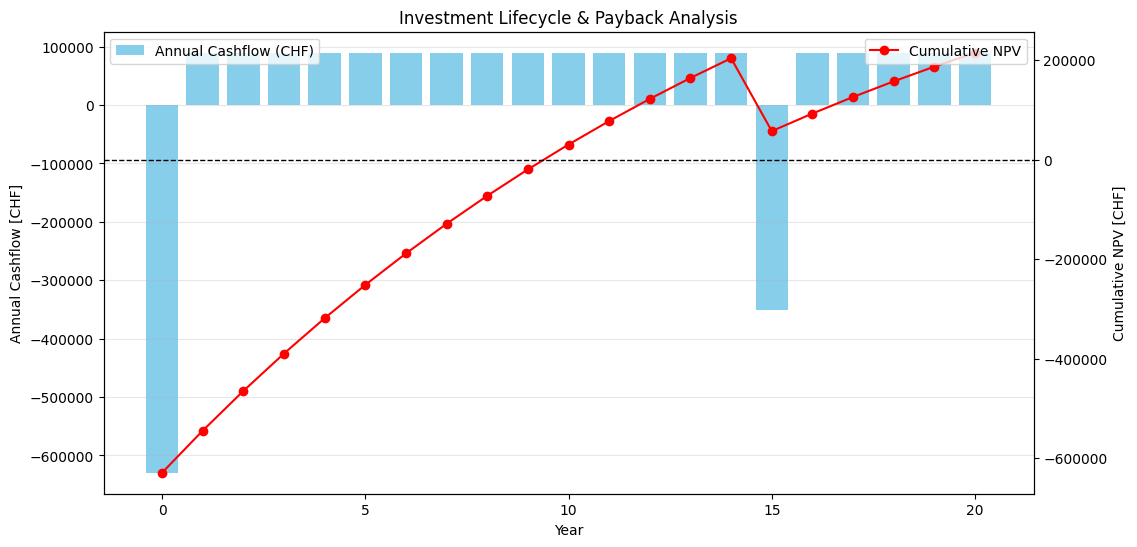

**Battery Energy Size:** 2,328.00 kWh

**Battery Power Rating:** 397.32 kW

**Energy CAPEX:** CHF 582,001.17

**Power CAPEX:** CHF 47,678.27

**Equivalent Full Cycles:** 170.61 cycles/year

...

**Internal Rate of Return (IRR):** 0.1078

**Battery Replacement:** CHF 440,775.60 in year 15

**Curtailed Energy:** 83,821.20 kWh/year

## Detailed Output Summary

,Metric,Value
0,battery_capacity_kwh,"2,328.00"
1,battery_power_capacity_kw,397.32
2,objective_total_cost,"660,865.93"
3,opex,"592,497.79"
4,import_cost,"582,497.79"
5,fixed_om_cost,"10,000.00"
6,annualized_battery_cost,"54,898.32"
7,peak_demand_cost,"13,469.82"
8,yearly_peak,"1,346.98"
9,monthly_peaks,{}


In [12]:
## 3. Financial Projection
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(df_fin['year'], df_fin['cashflow'], color='skyblue', label='Annual Cashflow (CHF)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Annual Cashflow [CHF]')

ax2 = ax1.twinx()
ax2.plot(df_fin['year'], df_fin['discounted_cashflow'].cumsum(), color='red', marker='o', label='Cumulative NPV')
ax2.axhline(0, color='black', linewidth=1, linestyle='--')
ax2.set_ylabel('Cumulative NPV [CHF]')

plt.title("Investment Lifecycle & Payback Analysis")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.3)
plt.show()

display(Markdown(f"**Battery Energy Size:** {summary.get('battery_capacity_kwh', 0):,.2f} kWh"))
display(Markdown(f"**Battery Power Rating:** {summary.get('battery_power_capacity_kw', 0):,.2f} kW"))
display(Markdown(f"**Energy CAPEX:** CHF {summary.get('energy_investment_cost', 0):,.2f}"))
display(Markdown(f"**Power CAPEX:** CHF {summary.get('power_investment_cost', 0):,.2f}"))
display(Markdown(f"**Equivalent Full Cycles:** {summary.get('equivalent_full_cycles', float('nan')):,.2f} cycles/year"))
display(Markdown(f"**Replacement Basis:** {summary.get('replacement_basis', 'N/A')}"))
display(Markdown(f"**Payback Period:** {summary.get('payback_years', 'N/A')} years"))
display(Markdown(f"**Discounted Payback Period:** {summary.get('discounted_payback_years', 'N/A')} years"))
display(Markdown(f"**Net Present Value (NPV):** CHF {summary.get('npv', 0):,.2f}"))
display(Markdown(f"**Internal Rate of Return (IRR):** {summary.get('irr', float('nan')):,.4f}"))
display(Markdown(f"**Battery Replacement:** CHF {summary.get('replacement_cost', 0):,.2f} in year {summary.get('replacement_year', 'N/A')}"))
display(Markdown(f"**Curtailed Energy:** {summary.get('curtailed_energy_kwh', 0):,.2f} kWh/year"))

display(Markdown("## Detailed Output Summary"))
display(detailed_summary_df.style.format({"Value": format_value}))